## **Ophiocordyceps Optimization Algorithm**

### **Caratteristiche dell'algoritmo**

1. **Inizializzazione: Disposizione delle formiche nello spazio delle soluzioni** \
Ogni formica rappresenta una possibile soluzione. All'inizio dell'algoritmo, le formiche vengono disposte casualmente nello spazio delle soluzioni, esplorando vari percorsi.

2. **Esplorazione: Movimento guidato dal personal best (Exploration)** \
Le formiche si muovono in base al miglior percorso trovato finora, ma con un certo grado di varianza per esplorare nuove soluzioni.

3. **Infezione: Infezione con probabilità e guida dal costo (Exploitation)** \
Durante ogni iterazione, una certa probabilità permette a una formica di infettarsi. Una volta infetta, la formica passa dalla fase di esplorazione alla fase di exploitation, spostandosi verso soluzioni più ottimali, guidate dal costo (o funzione obiettivo).

4. **Morte e dispersione delle spore** \
Una formica infetta muore quando raggiunge una certa soglia di miglioramento della soluzione (ad esempio, un certo numero di passi o il miglioramento del costo) o dopo un numero massimo di passi. Le spore sono più concentrate nelle zone promettenti, spingendo le formiche vicine a esplorare quelle aree in modo più intensivo.

5. **Fine dell'iterazione: Selezione e rinnovo delle formiche** \
Alla fine di ogni iterazione le aree meno esplorate o con soluzioni peggiori vengono eliminate o "sfumate", riducendo l'area di ricerca. Poi vengono introdotte nuove formiche in zone inesplorate dello spazio delle soluzioni, aumentando la diversità nella ricerca.

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

class Ant:
    def __init__(self, position, fitness=None):
        self.position = position  # Vettore posizione nello spazio degli stati
        self.fitness = fitness    # Valore di fitness (None finché non viene calcolato)
        self.is_infected = False  # Flag per indicare se la formica è infetta
        self.is_alive = True      # Flag per indicare se la formica è in vita
        
    def __str__(self):
        return f"ant at: {self.position}, fitness/cost: {self.fitness}, infected: {self.is_infected}, alive: {self.is_alive}"

class Spore:
    def __init__(self, position):
        self.position = position
        self.age = 0

def dispatch_ants(n, dims, lower_bound, upper_bound):
    ants = []
    
    # Converti i limiti in array numpy se non lo sono già
    lower_bound = np.array(lower_bound)
    upper_bound = np.array(upper_bound)
    
    # Verifica che i limiti abbiano le dimensioni corrette
    if len(lower_bound) != dims or len(upper_bound) != dims:
        raise ValueError(f"I limiti devono avere lunghezza {dims}")
    
    # Genera n formiche con posizioni casuali
    for _ in range(n):
        # Genera un vettore casuale nello spazio degli stati
        position = lower_bound + np.random.random(dims) * (upper_bound - lower_bound)
        
        # Crea una nuova formica con la posizione generata
        ant = Ant(position)
        ants.append(ant)
    
    return ants

# Funzione per simulare il moto browniano
def borwnian_walk(coords, step_size=0.01, sigma=1.0):
    return coords + sigma * np.sqrt(step_size) * np.random.normal(0, 1, size=coords.shape)

def update_spores(spores, age_limit=10):
    for spore in spores:
        spore.age += 1
    return [spore for spore in spores if spore.age < age_limit]

def ant_in_range(ant_position, spore_position, spore_radius):
    return np.linalg.norm(ant_position - spore_position) < spore_radius

def max_fit(ants):
    best_ant = Ant([0,0],-np.inf)
    for ant in ants:
        if ant.fitness > best_ant.fitness:
            best_ant = ant
    return best_ant

def min_fit(ants):
    best_ant = Ant([0,0],np.inf)
    for ant in ants:
        if ant.fitness < best_ant.fitness:
            best_ant = ant
    return best_ant

In [48]:
# FUNZIONI DI FITNESS BENCHMARK
def sphere(x):
    x = np.array(x)
    return -np.sum(x**2)

def rastrigin(x):
    x = np.array(x)
    return 10 * len(x) + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))

def ackley(x):
    x = np.array(x)
    a = 20
    b = 0.2
    c = 2 * np.pi
    n = len(x)
    sum_sq = np.sum(x**2)
    sum_cos = np.sum(np.cos(c * x))
    return -a * np.exp(-b * np.sqrt(sum_sq / n)) - np.exp(sum_cos / n) + a + np.exp(1)

def griewank(x):
    x = np.array(x)
    sum_term = np.sum(x**2) / 4000
    prod_term = np.prod(np.cos(x / np.sqrt(np.arange(1, len(x) + 1))))
    return sum_term - prod_term + 1

def levy(x):
    x = np.array(x)
    w = 1 + (x - 1) / 4
    term1 = np.sin(np.pi * w[0])**2
    term3 = (w[-1] - 1)**2 * (1 + np.sin(2 * np.pi * w[-1])**2)
    term2 = np.sum((w[:-1] - 1)**2 * (1 + 10 * np.sin(np.pi * w[:-1] + 1)**2))
    return term1 + term2 + term3

def f2DPSO(x):
    x = np.array(x)
    return (x[0]-3.14)**2 + (x[1]-2.72)**2 + np.sin(3*x[0]+1.41) + np.sin(4*x[1]-1.73)

# funzione di stima del gradiente
def estimate_gradient(fitness, position, epsilon=1e-6):
    grad = np.zeros_like(position)
    for i in range(len(position)):
        pos_up = np.array(position)
        pos_down = np.array(position)
        pos_up[i] += epsilon
        pos_down[i] -= epsilon
        grad[i] = (fitness(pos_up) - fitness(pos_down)) / (2 * epsilon)
    return grad

In [49]:
from matplotlib import cm


def plot(ants, spores, lower_bound, upper_bound, fitness_function, 
                               resolution=100, figsize=(8, 6), cmap='viridis', 
                               title="Ant positioning"):
    """
    Visualizza una qualsiasi funzione di fitness con le posizioni delle formiche usando una mappa di colori 2D
    """
    if len(ants[0].position) != 2:
        raise ValueError("La visualizzazione è possibile solo per spazi 2D")
    
    # Determina i limiti effettivi basati sulle posizioni delle formiche
    ant_x = [ant.position[0] for ant in ants]
    ant_y = [ant.position[1] for ant in ants]

    spore_x = [spore.position[0] for spore in spores] if spores is not None else [np.nan]
    spore_y = [spore.position[1] for spore in spores] if spores is not None else [np.nan]
    
    # Usa i limiti forniti o calcola dai dati delle formiche
    actual_lower_x = min(min(ant_x), lower_bound[0])
    actual_upper_x = max(max(ant_x), upper_bound[0])
    actual_lower_y = min(min(ant_y), lower_bound[1])
    actual_upper_y = max(max(ant_y), upper_bound[1])
    
    # Crea griglia di punti per x e y usando i limiti effettivi
    x = np.linspace(actual_lower_x, actual_upper_x, resolution)
    y = np.linspace(actual_lower_y, actual_upper_y, resolution)
    X, Y = np.meshgrid(x, y)
    
    # Calcola il valore della funzione per l'intera area
    Z = np.zeros_like(X)
    for i in range(len(x)):
        for j in range(len(y)):
            Z[j, i] = fitness_function([X[j, i], Y[j, i]])
    
    # Crea figura
    plt.figure(figsize=figsize)
    
    # Grafico 2D con mappa di colori sull'intera area
    contour = plt.contourf(X, Y, Z, 50, cmap=cm.get_cmap(cmap), alpha=0.8)
    
    # Aggiungi linee di contorno
    plt.contour(X, Y, Z, 15, colors='black', alpha=0.3, linewidths=0.5)
    
    # Aggiungi le formiche
    colors = ['black' if not ant.is_alive else 'red' if ant.is_infected else 'blue' for ant in ants]
    
    plt.scatter(ant_x, ant_y, c=colors, edgecolor='white', s=80, zorder=5)
    plt.scatter(spore_x, spore_y, c='orange', edgecolor='white', s=80, zorder=5)
    
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Barra dei colori
    cbar = plt.colorbar(contour)
    cbar.set_label('Valore della funzione')
    
    # Legenda
    legend_elements = [
        Patch(facecolor='blue', edgecolor='black', label='Formica sana'),
        Patch(facecolor='red', edgecolor='black', label='Formica infetta'),
        Patch(facecolor='black', edgecolor='black', label='Formica morta'),
        Patch(facecolor='orange', edgecolor='black', label='Spore')
    ]
    
    plt.legend(handles=legend_elements, loc='best')
    plt.tight_layout()
    plt.show()

### **Definizione dell'Algoritmo** 

In [ ]:
def ophiocordyceps(n_ants, n_dims, lower_bound, upper_bound, fitness, minimization=False, spore_age_limit=10, spore_radius=0.1, learning_rate=0.05, ant_step_size=0.01, base_infection_prob=0.1, death_prob=0.1, max_iter=20):
    # Inizializzazione delle formiche
    ants = dispatch_ants(n_ants, n_dims, lower_bound, upper_bound)
    spores = []
    best = 0

    print("Inizializzazione...")
    if n_dims == 2:
        plot(ants, spores, lower_bound, upper_bound, fitness)
    
    # Avvio dell'algoritmo
    for i in range(max_iter):
        for ant in [a for a in ants if a.is_alive]: # itero sulle formiche in vita

            infection_prob = base_infection_prob # la probabilità di infezione di base viene resettata per ogni formica
        
            # Spostamento delle formiche nello spazio
            if ant.is_infected:
                # walk della formica guidata dal costo
                gradient = estimate_gradient(fitness, ant.position)
                if not minimization:
                    ant.position = ant.position + learning_rate * gradient
                else:
                    ant.position = ant.position - learning_rate * gradient
            else:
                # walk della formica nello spazio delle soluzioni con moto browniano
                ant.position = borwnian_walk(ant.position, step_size=ant_step_size)

            # Calcola e aggiorna la fitness
            ant.fitness = fitness(ant.position)

            # Infezione delle formiche
            for spore in spores:
                if ant_in_range(ant.position,spore.position,spore_radius): 
                    infection_prob += (base_infection_prob*0.5) # se la formica è nei pressi di una spora ha probabilità aumentata di venire infettata
                
            ant.is_infected = ant.is_infected or (np.random.rand() <= infection_prob)

            # Morte delle formiche infette
            if ant.is_infected:
                if np.random.rand() <= death_prob: #COME LE FACCIO MORIRE? PROBABILITA'? MEGLIO GUIDATE DAL COSTO MI SA
                    ant.is_alive = False
                    ant.is_infected = False
                    # Rilascio delle spore
                    spores.append(Spore(ant.position))
                    
        # Fine iterazione
        spores = update_spores(spores, spore_age_limit) # aggiornamento delle spore

        if not minimization:
            best = max_fit([ant for ant in ants if ant.fitness is not None]) # aggiornamento del best per max
        else:
            best = min_fit([ant for ant in ants if ant.fitness is not None]) # aggiornamento del best per min

        print("Iteration: " + str(i+1) + " | Best " + str(best)) # stampa informazioni
        if n_dims == 2:
            plot(ants, spores, lower_bound, upper_bound, fitness)


### **Esecuzione dell'algoritmo**

Inizializzazione...


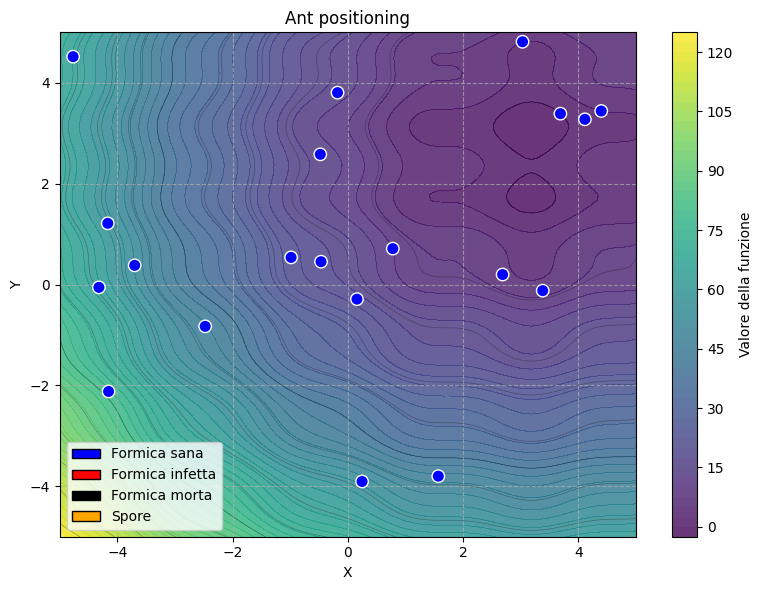

Iteration: 1 | Best ant at: [3.66643738 3.5141304 ], fitness/cost: 0.5138098522110208, infected: False, alive: True


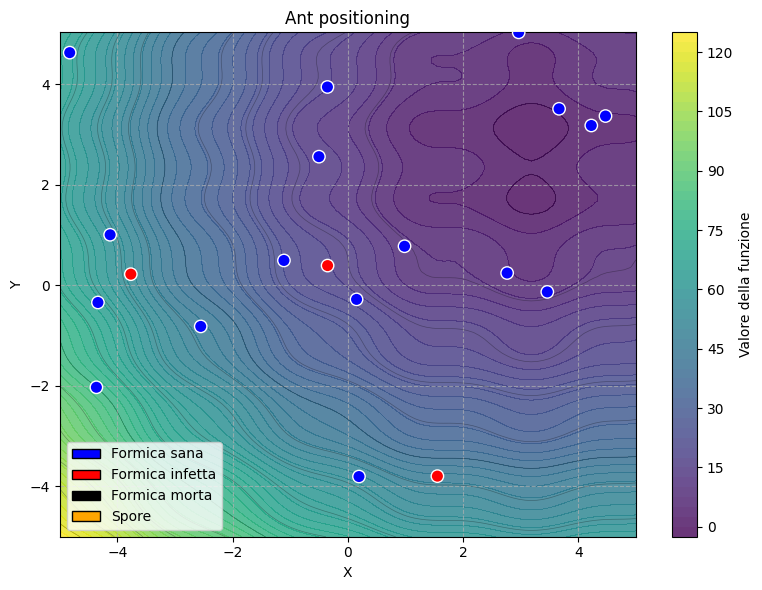

Iteration: 2 | Best ant at: [3.79886976 3.45774869], fitness/cost: 0.7675582136443954, infected: False, alive: True


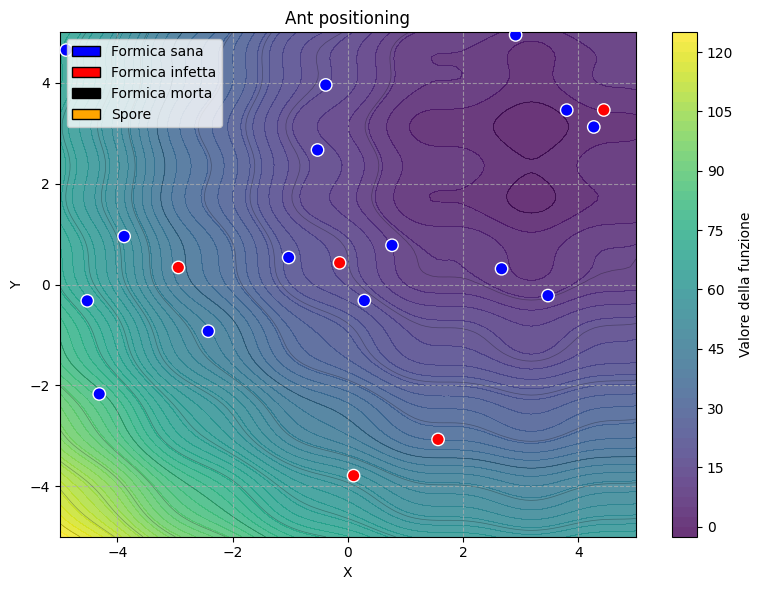

Iteration: 3 | Best ant at: [3.75398451 3.18685245], fitness/cost: -0.299446551340514, infected: False, alive: True


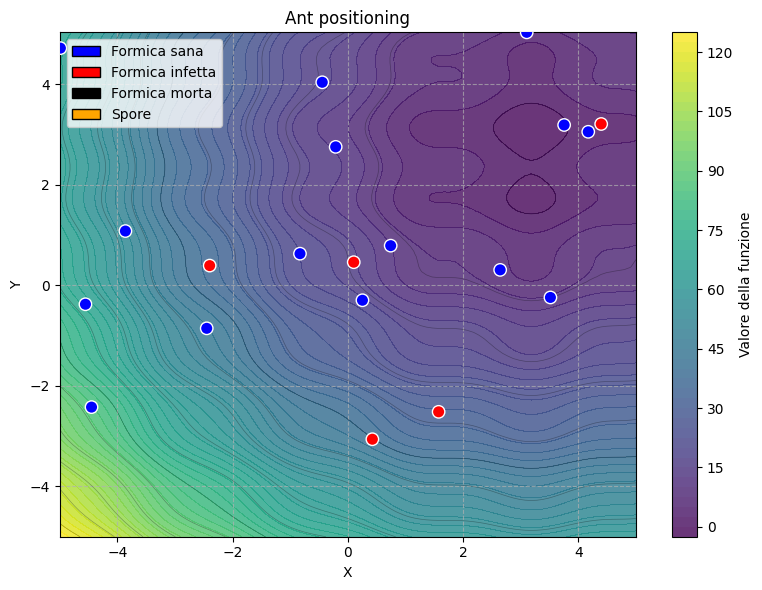

Iteration: 4 | Best ant at: [3.63502703 3.03127549], fitness/cost: -0.7317778318601234, infected: False, alive: True


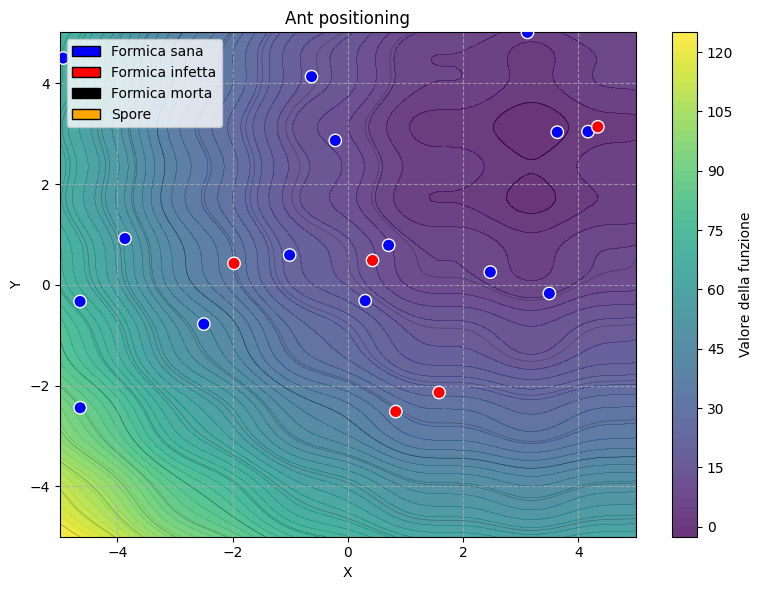

Iteration: 5 | Best ant at: [3.90870708 3.1373135 ], fitness/cost: 0.319987419390265, infected: False, alive: True


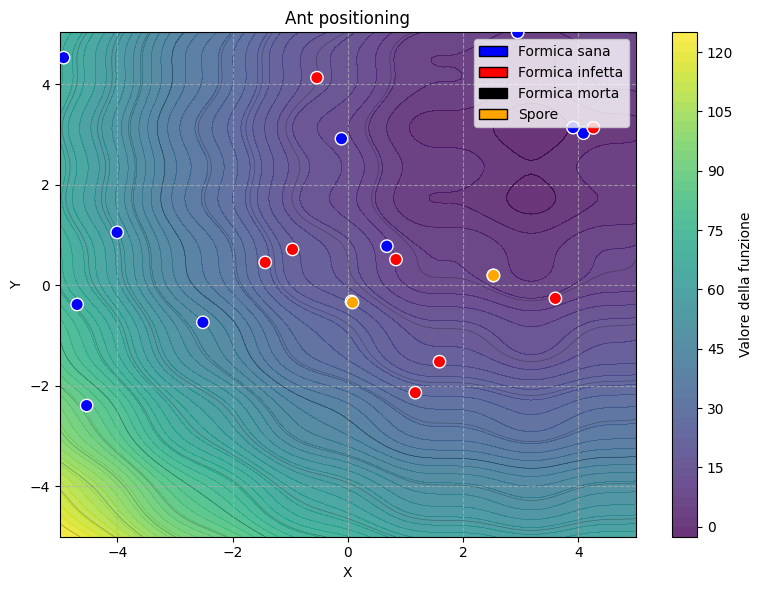

Iteration: 6 | Best ant at: [3.84713507 3.36951888], fitness/cost: 0.567524346485855, infected: False, alive: True


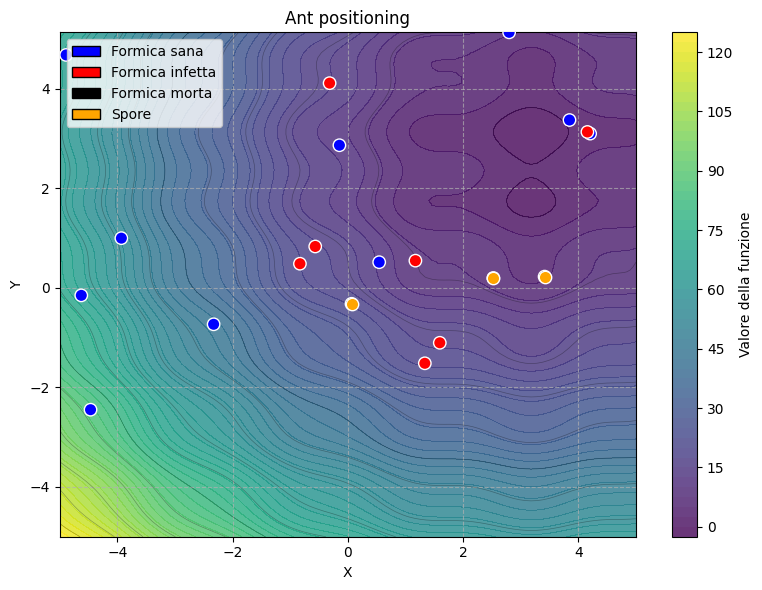

Iteration: 7 | Best ant at: [3.91291554 3.32366248], fitness/cost: 0.6694172330619046, infected: False, alive: True


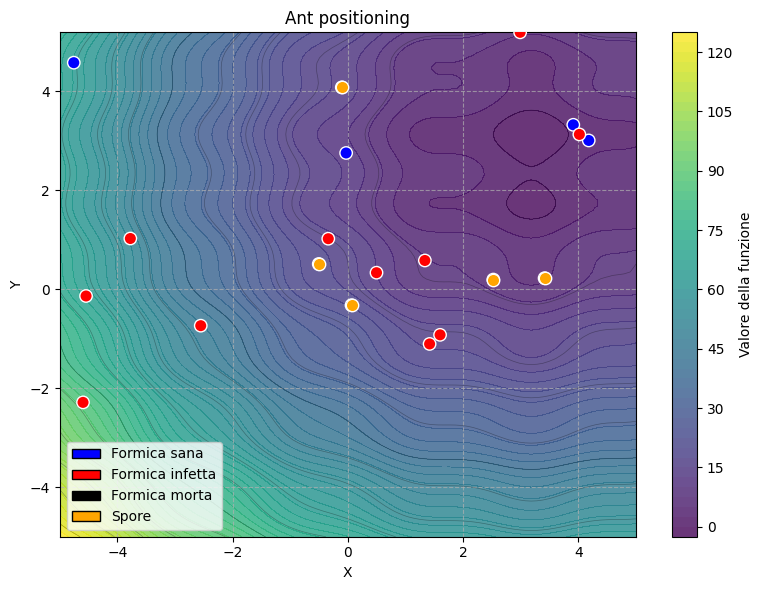

Iteration: 8 | Best ant at: [3.8371844  3.12980429], fitness/cost: 0.022983374368092835, infected: True, alive: True


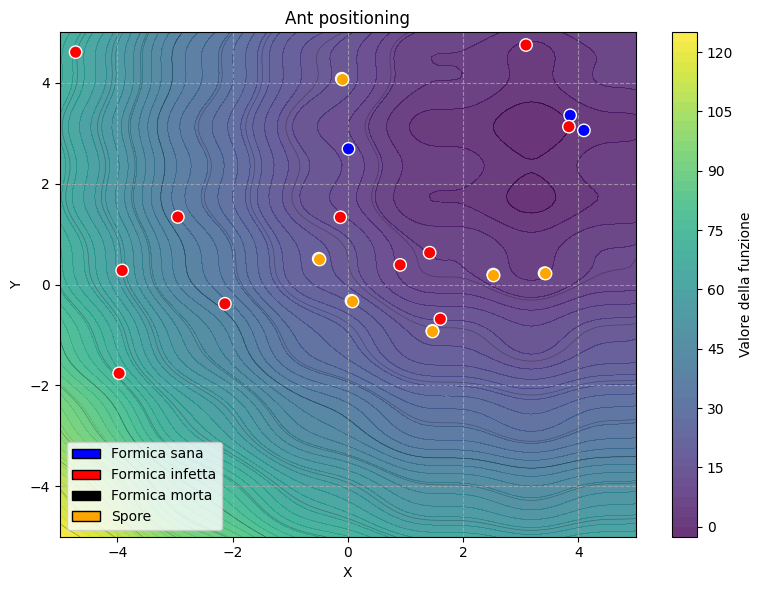

Iteration: 9 | Best ant at: [3.62682851 3.129803  ], fitness/cost: -0.8462409377507737, infected: False, alive: False


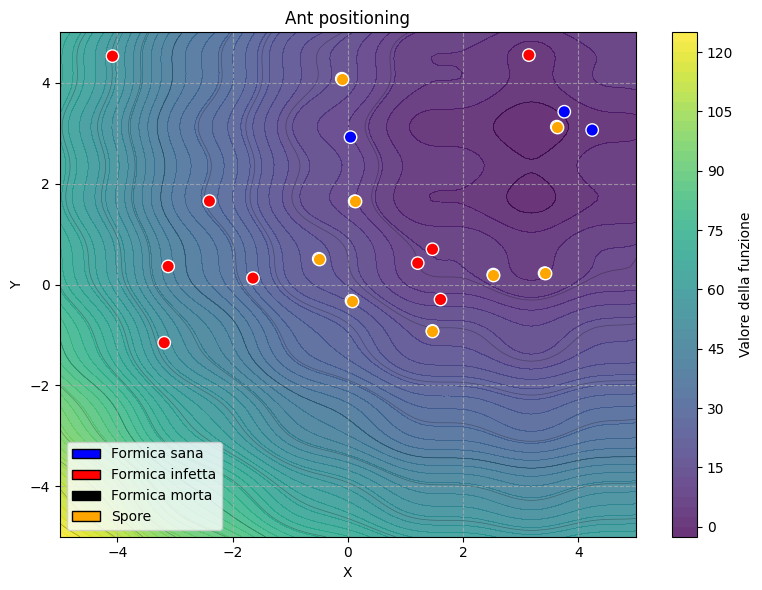

Iteration: 10 | Best ant at: [3.62682851 3.129803  ], fitness/cost: -0.8462409377507737, infected: False, alive: False


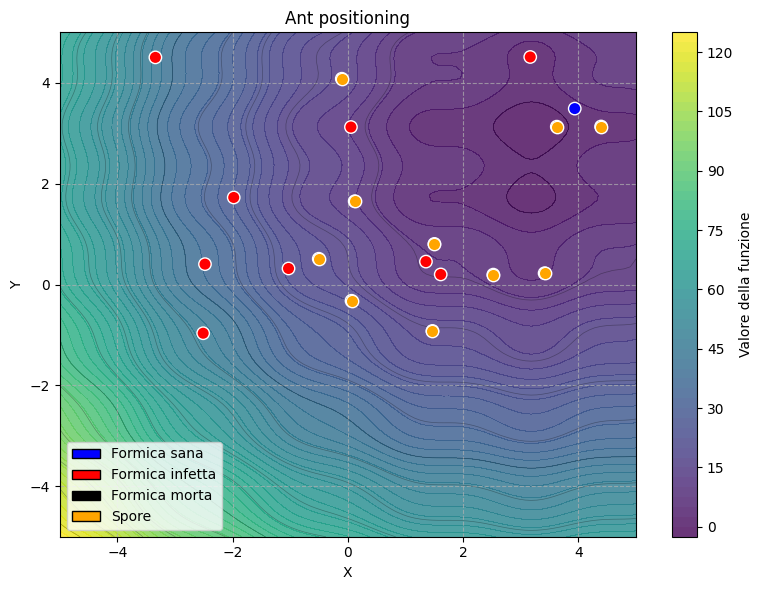

Iteration: 11 | Best ant at: [3.62682851 3.129803  ], fitness/cost: -0.8462409377507737, infected: False, alive: False


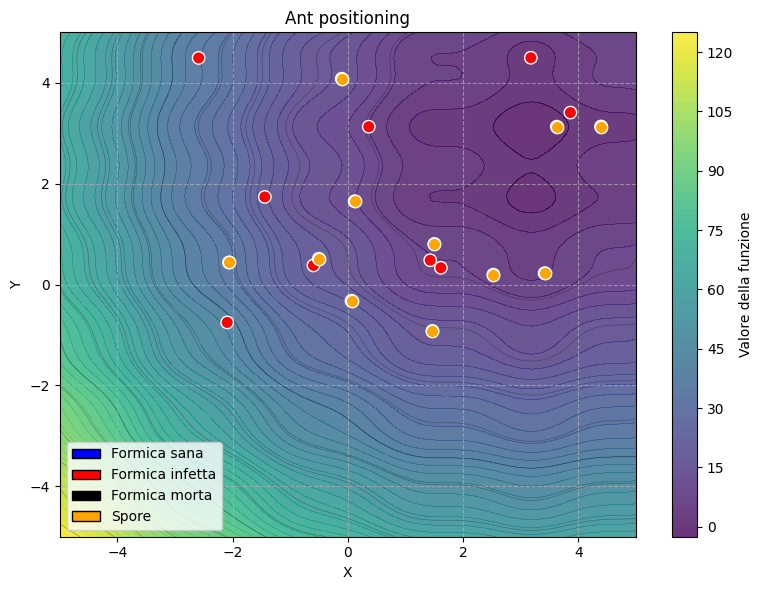

Iteration: 12 | Best ant at: [3.62682851 3.129803  ], fitness/cost: -0.8462409377507737, infected: False, alive: False


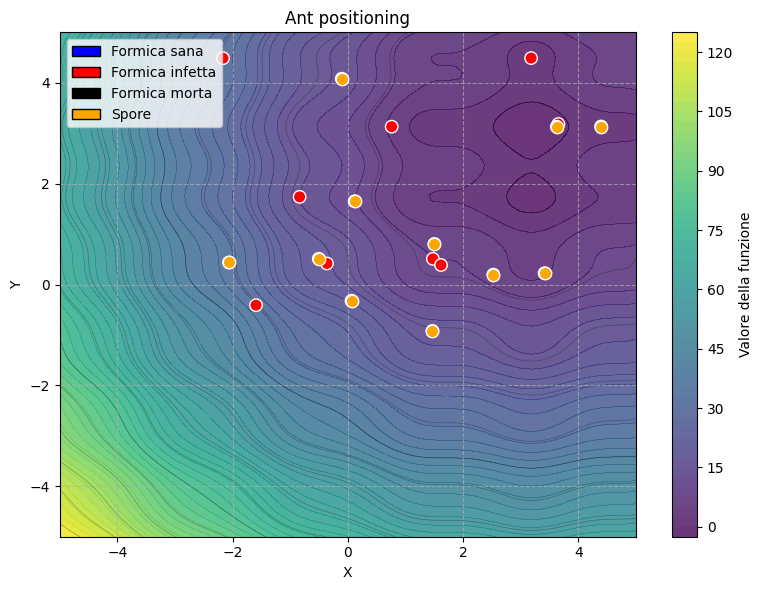

Iteration: 13 | Best ant at: [3.45592181 3.13531242], fitness/cost: -1.4201401260735258, infected: False, alive: False


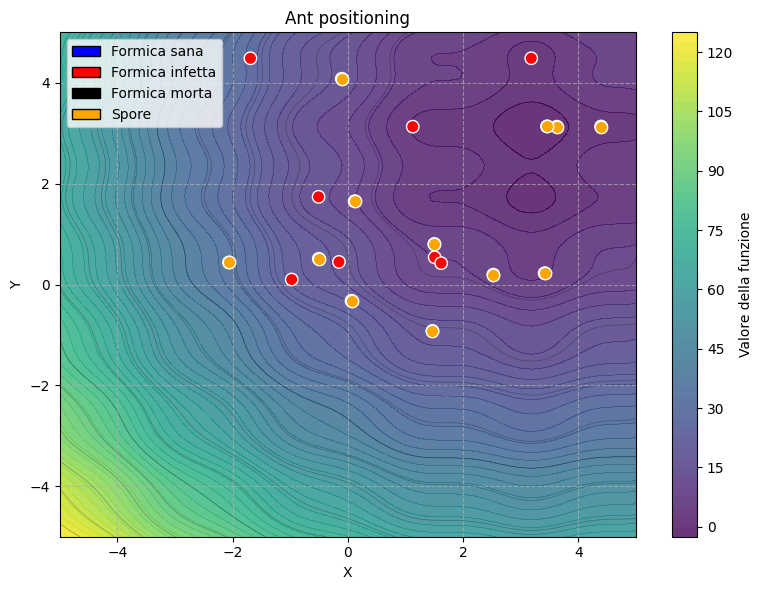

Iteration: 14 | Best ant at: [3.45592181 3.13531242], fitness/cost: -1.4201401260735258, infected: False, alive: False


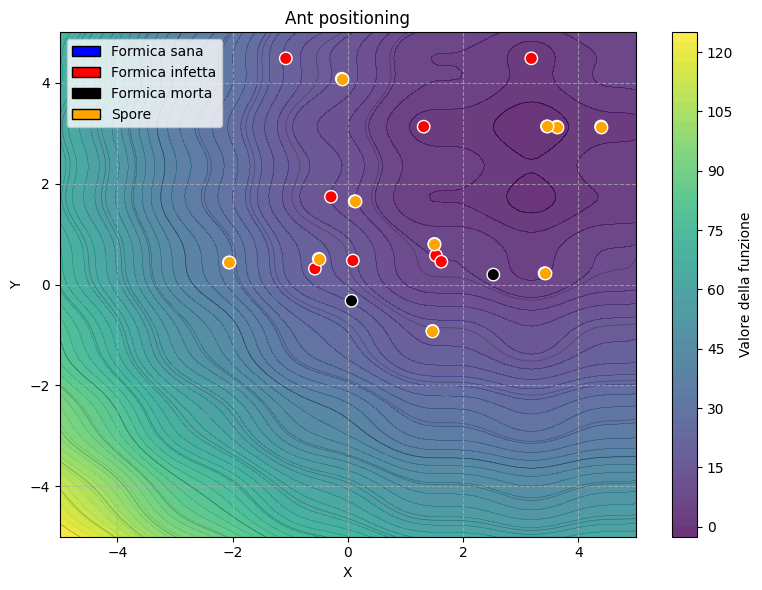

Iteration: 15 | Best ant at: [3.45592181 3.13531242], fitness/cost: -1.4201401260735258, infected: False, alive: False


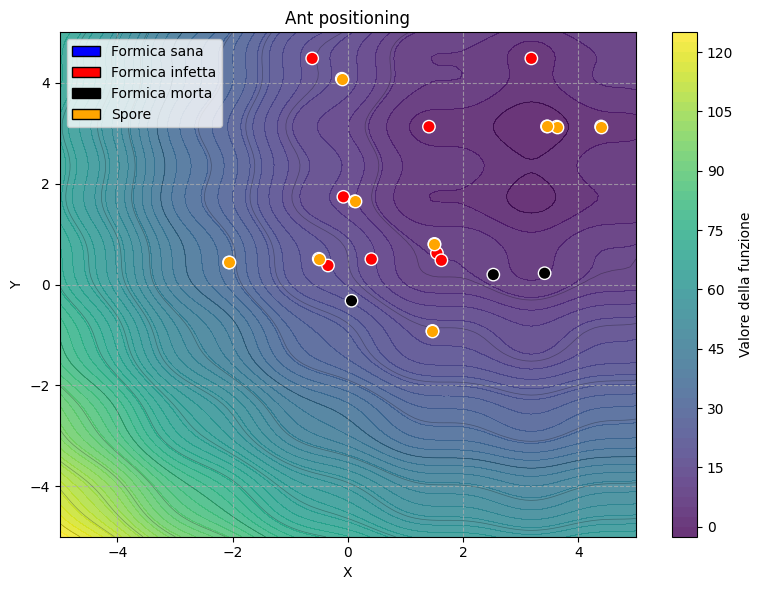

Iteration: 16 | Best ant at: [3.45592181 3.13531242], fitness/cost: -1.4201401260735258, infected: False, alive: False


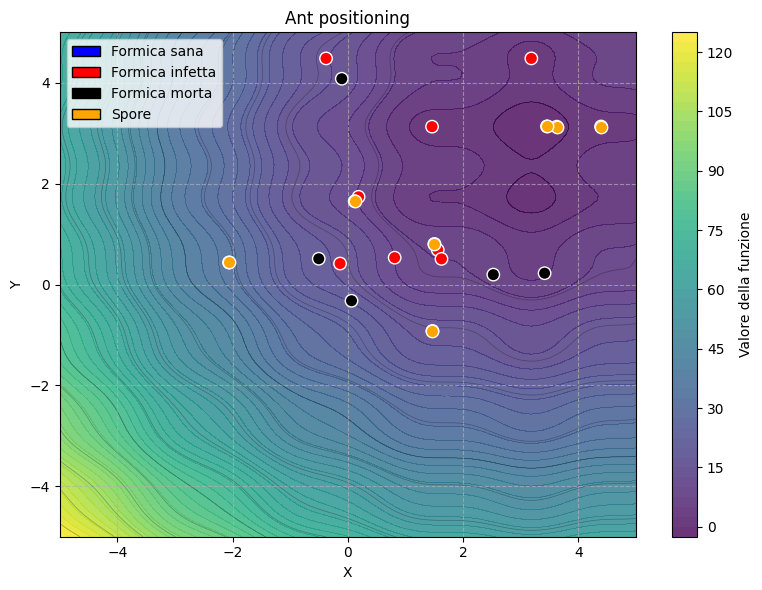

Iteration: 17 | Best ant at: [3.45592181 3.13531242], fitness/cost: -1.4201401260735258, infected: False, alive: False


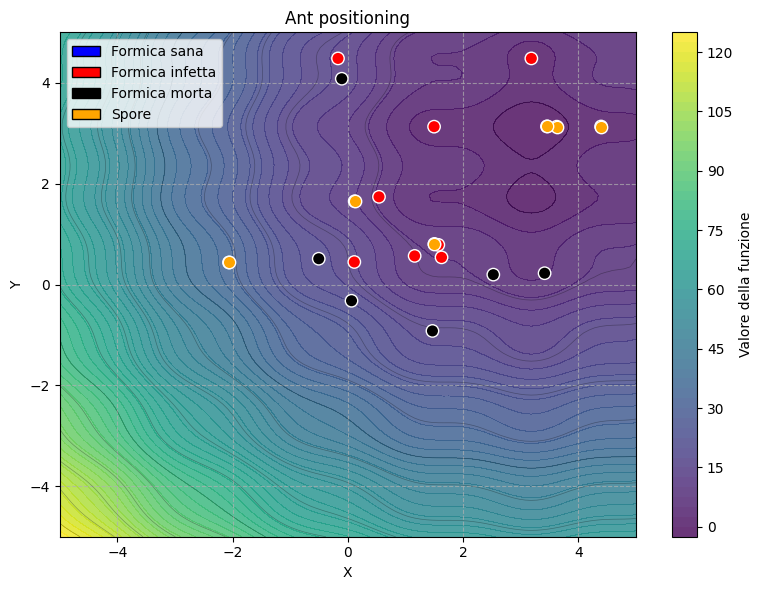

Iteration: 18 | Best ant at: [3.45592181 3.13531242], fitness/cost: -1.4201401260735258, infected: False, alive: False


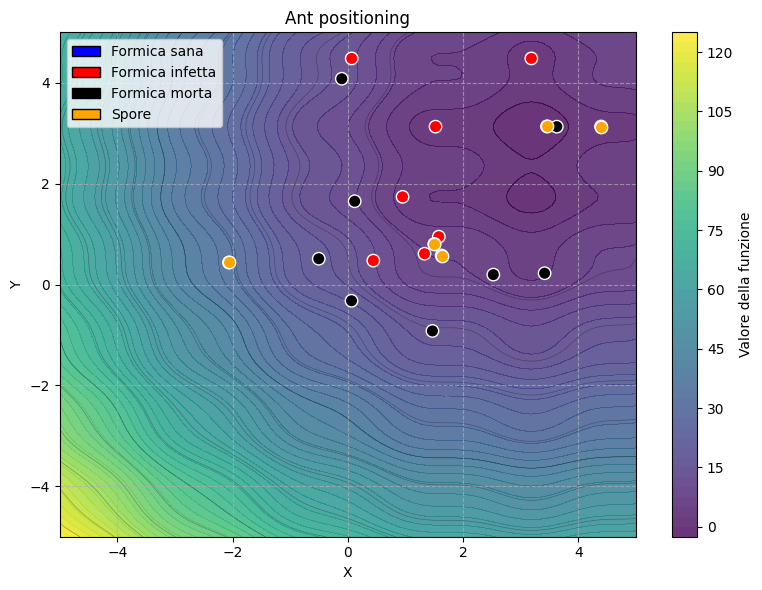

Iteration: 19 | Best ant at: [3.45592181 3.13531242], fitness/cost: -1.4201401260735258, infected: False, alive: False


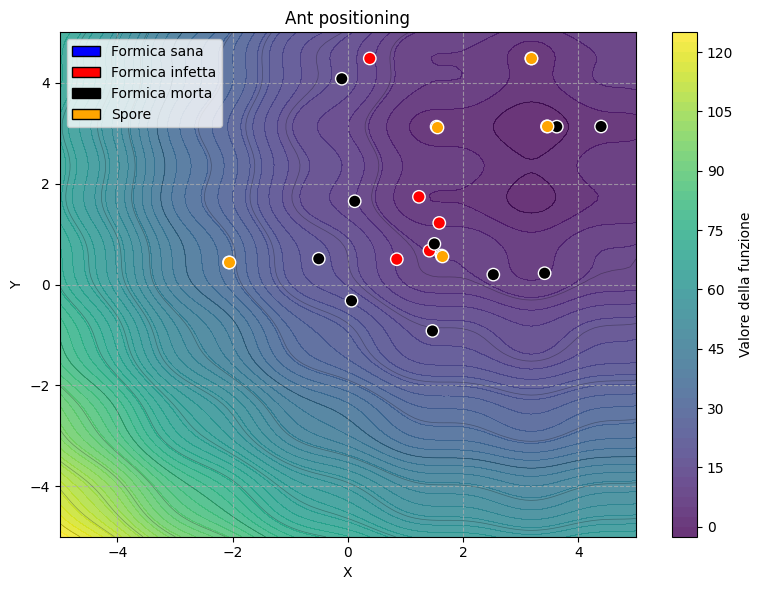

Iteration: 20 | Best ant at: [3.45592181 3.13531242], fitness/cost: -1.4201401260735258, infected: False, alive: False


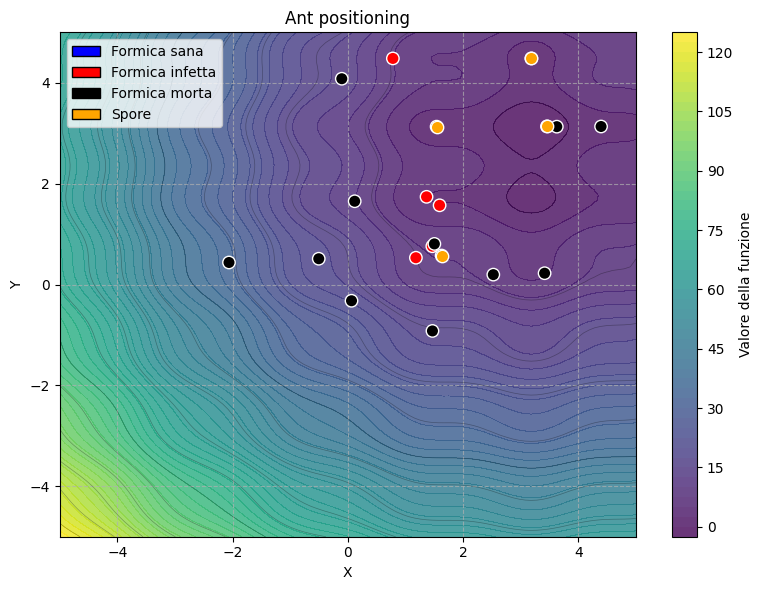

In [58]:
if __name__ == "__main__":
    # Parametri
    n_formiche = 20
    dimensioni = 2
    limiti_inf = [-5, -5]
    limiti_sup = [5, 5]
    probabilità_infezione = 0.1
    probabilità_morte = 0.1
    max_iter = 20
    passo_formiche = 0.01
    learning_rate = 0.05
    permanenza_spore = 10
    raggio_spore=10

    #np.random.seed(100)

    # Avvio dell'algoritmo
    ophiocordyceps(n_formiche, dimensioni, limiti_inf, limiti_sup, fitness=f2DPSO, minimization=True,
                   spore_age_limit=permanenza_spore,
                   spore_radius=raggio_spore,
                   base_infection_prob=probabilità_infezione, 
                   death_prob=probabilità_morte,
                   ant_step_size= passo_formiche,
                   max_iter=max_iter, learning_rate=learning_rate)